In [2]:
%pip install pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import re

# Read + Store Data CSVs

In [19]:
#creates Path object pointing to folder
data_path = Path("/Users/kierachiu/Documents/IDX Exchange/IDX-Exchange-Data-Science/data/csv")

#creates empty list to store wanted files
files = []

for file in data_path.glob("CRMLSSold*.csv"): #looking for specific format
    if re.fullmatch(r"CRMLSSold\d{6}(?:_filled)?.csv", file.name):
        files.append(file)

#sort files based on characters 9-14 (date)
files.sort(key=lambda file: file.name[9:15]) 

df = pd.concat([pd.read_csv(file, low_memory=False) for file in files], ignore_index=True)
df.shape

(615707, 84)

In [5]:
#double check concatenation 
expected_rows = sum(
    pd.read_csv(file, low_memory=False).shape[0]
    for file in files
)

actual_rows = df.shape[0]

print("Expected rows:", expected_rows)
print("Actual rows:", actual_rows)
print("Rows match:", expected_rows == actual_rows)

Expected rows: 615707
Actual rows: 615707
Rows match: True


# CSV Summary

In [6]:
cols_dictionary = {}  

#add file name and list of columns into dictionary
for file in files:  
    cols = pd.read_csv(file, nrows=0).columns.tolist() 
    cols_dictionary[file.name] = cols  

#use first file as comparison reference 
ref_name = files[0].name 
ref_cols = cols_dictionary[ref_name]  
ref_set = set(ref_cols)  

print(f"Reference file: {ref_name}")  
print(f"Reference column count: {len(ref_cols)}") 

for name, cols in cols_dictionary.items(): 
    extra = sorted(set(cols) - ref_set) 
    missing = sorted(ref_set - set(cols)) 

    if extra or missing:  
        print(f"\n{name}: {len(cols)} columns")
        print(f"Extra count: {len(extra)}")
        print(f"Missing count: {len(missing)}")
        print(f"  Extra:   {extra}")
        print(f"  Missing: {missing}")

Reference file: CRMLSSold202401_filled.csv
Reference column count: 80

CRMLSSold202402.csv: 78 columns
Extra count: 0
Missing count: 2
  Extra:   []
  Missing: ['latfilled', 'lonfilled']

CRMLSSold202405_filled.csv: 80 columns
Extra count: 2
Missing count: 2
  Extra:   ['BuyerAgentAOR', 'ListAgentAOR']
  Missing: ['BuyerAgencyCompensation', 'BuyerAgencyCompensationType']

CRMLSSold202406_filled.csv: 80 columns
Extra count: 2
Missing count: 2
  Extra:   ['BuyerAgentAOR', 'ListAgentAOR']
  Missing: ['BuyerAgencyCompensation', 'BuyerAgencyCompensationType']

CRMLSSold202407_filled.csv: 80 columns
Extra count: 2
Missing count: 2
  Extra:   ['BuyerAgentAOR', 'ListAgentAOR']
  Missing: ['BuyerAgencyCompensation', 'BuyerAgencyCompensationType']

CRMLSSold202408.csv: 78 columns
Extra count: 2
Missing count: 4
  Extra:   ['BuyerAgentAOR', 'ListAgentAOR']
  Missing: ['BuyerAgencyCompensation', 'BuyerAgencyCompensationType', 'latfilled', 'lonfilled']

CRMLSSold202409.csv: 78 columns
Extra count: 

In [7]:
summary = []

for file in files:
    df_temp = pd.read_csv(file, low_memory=False) #stores current file

    #creates dictionary with basic info abt file and adds to summary
    summary.append({
        "file": file.name,
        "rows": len(df_temp),
        "columns": len(df_temp.columns),
        "missing_cells": df_temp.isna().sum().sum(),
        "duplicate_rows": df_temp.duplicated().sum()
    })

summary_df = pd.DataFrame(summary) #list of dictionaries converted to data frame

summary_df

,file,rows,columns,missing_cells,duplicate_rows
0,CRMLSSold202401_filled.csv,17958,80,448498,0
1,CRMLSSold202402.csv,19925,78,502870,0
2,CRMLSSold202403_filled.csv,23276,80,574445,0
3,CRMLSSold202404_filled.csv,24640,80,607044,0
4,CRMLSSold202405_filled.csv,26487,80,652826,0
5,CRMLSSold202406_filled.csv,24328,80,598751,0
6,CRMLSSold202407_filled.csv,26240,80,644453,0
7,CRMLSSold202408.csv,24558,78,603795,81
8,CRMLSSold202409.csv,21267,78,522202,11
9,CRMLSSold202410.csv,23274,78,572029,4


In [8]:
df.shape
df.head()

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
0,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,94401,6472.0,NaN,NaN,True,True,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,0.0,535486633,eabrown@lee-associates.com,2024-01-24,950.0,...,92394,NaN,52320.0,NaN,False,False,NaN,NaN,NaN,NaN
2,NaN,True,NaN,NaN,NaN,75000.0,529986282,Joe@9WINWIN.com,2024-01-16,45000.0,...,93240,NaN,217364.0,NaN,False,False,NaN,NaN,NaN,NaN
3,NaN,True,NaN,NaN,NaN,199000.0,529618166,carolthefinder@yahoo.com,2024-01-08,141500.0,...,92308,NaN,217800.0,NaN,False,False,NaN,NaN,NaN,NaN
4,NaN,True,NaN,NaN,NaN,19500.0,522614340,jtavisola@tavisola.com,2024-01-17,15000.0,...,93544,0.0,108883.0,NaN,False,False,NaN,NaN,NaN,NaN


In [9]:
df.columns.tolist()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 615707 entries, 0 to 615706
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Flooring                      361814 non-null  str    
 1   ViewYN                        554072 non-null  object 
 2   WaterfrontYN                  339 non-null     object 
 3   BasementYN                    10159 non-null   object 
 4   PoolPrivateYN                 538866 non-null  object 
 5   OriginalListPrice             613919 non-null  float64
 6   ListingKey                    615707 non-null  int64  
 7   ListAgentEmail                614195 non-null  str    
 8   CloseDate                     615707 non-null  str    
 9   ClosePrice                    615700 non-null  float64
 10  ListAgentFirstName            612159 non-null  str    
 11  ListAgentLastName             615645 non-null  str    
 12  Latitude                      610319 non-null  float64


In [10]:
df["PropertySubType"].value_counts(dropna=False).head(20)

PropertySubType
SingleFamilyResidence    376086
Condominium              107040
NaN                       47066
Townhouse                 35545
Apartment                 14185
Duplex                    11759
ManufacturedOnLand         6232
Quadruplex                 3667
Triplex                    3666
StockCooperative           2076
MixedUse                   1894
Office                     1656
Retail                     1102
Industrial                  705
Cabin                       525
Studio                      449
Business                    411
RoomingHouse                310
Warehouse                   308
SpecialPurpose              155
Name: count, dtype: int64

In [11]:
df["PropertyType"].value_counts(dropna=False).head(20)

PropertyType
Residential            414054
ResidentialLease       140960
Land                    20038
ManufacturedInPark      16706
ResidentialIncome       16476
CommercialSale           3843
CommercialLease          3216
BusinessOpportunity       414
Name: count, dtype: int64

In [12]:
#filters dataset to only keep Residential and SingleFamilyResidence rows
df_res = df[(df["PropertyType"] == "Residential") &
    (df["PropertySubType"] == "SingleFamilyResidence")].copy()
print(df_res.shape)
df.columns.tolist()

(309735, 84)


['Flooring',
 'ViewYN',
 'WaterfrontYN',
 'BasementYN',
 'PoolPrivateYN',
 'OriginalListPrice',
 'ListingKey',
 'ListAgentEmail',
 'CloseDate',
 'ClosePrice',
 'ListAgentFirstName',
 'ListAgentLastName',
 'Latitude',
 'Longitude',
 'UnparsedAddress',
 'PropertyType',
 'LivingArea',
 'ListPrice',
 'DaysOnMarket',
 'ListOfficeName',
 'BuyerOfficeName',
 'CoListOfficeName',
 'ListAgentFullName',
 'CoListAgentFirstName',
 'CoListAgentLastName',
 'BuyerAgentMlsId',
 'BuyerAgentFirstName',
 'BuyerAgentLastName',
 'FireplacesTotal',
 'AssociationFeeFrequency',
 'AboveGradeFinishedArea',
 'ListingKeyNumeric',
 'MLSAreaMajor',
 'TaxAnnualAmount',
 'CountyOrParish',
 'MlsStatus',
 'ElementarySchool',
 'AttachedGarageYN',
 'ParkingTotal',
 'BuilderName',
 'PropertySubType',
 'LotSizeAcres',
 'SubdivisionName',
 'BuyerOfficeAOR',
 'YearBuilt',
 'BuyerAgencyCompensationType',
 'StreetNumberNumeric',
 'ListingId',
 'BathroomsTotalInteger',
 'City',
 'BuyerAgencyCompensation',
 'TaxYear',
 'BuildingA

In [13]:
cols = ["ClosePrice", "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeAcres", "LotSizeArea", "LotSizeSquareFeet"]

df_res[cols].describe()

,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeAcres,LotSizeArea,LotSizeSquareFeet
count,3.097330e+05,309569.000000,309735.000000,309685.000000,3.043810e+05,3.044320e+05,3.044080e+05
mean,1.297553e+06,2033.883475,3.480905,2.616581,3.811137e+01,2.094266e+04,2.666652e+05
std,5.643293e+06,1058.296353,0.961522,1.199603,1.421163e+04,7.049530e+05,1.460283e+07
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.250000e+05,1376.000000,3.000000,2.000000,1.300000e-01,5.466000e+03,5.663000e+03
50%,8.940000e+05,1804.000000,3.000000,2.000000,1.663000e-01,7.100000e+03,7.245000e+03
75%,1.430000e+06,2421.000000,4.000000,3.000000,2.376000e-01,9.906000e+03,1.035000e+04
max,9.895000e+08,123764.000000,45.000000,175.000000,7.810698e+06,2.178000e+08,2.087221e+09


In [14]:
df_res[cols].isna().sum()

ClosePrice                  2
LivingArea                166
BedroomsTotal               0
BathroomsTotalInteger      50
LotSizeAcres             5354
LotSizeArea              5303
LotSizeSquareFeet        5327
dtype: int64

# Data Visualization

In [15]:
comparison = pd.concat([df_res["BedroomsTotal"].value_counts(), df_res["BathroomsTotalInteger"].value_counts()],axis=1)
comparison.columns = ["BedroomsTotal", "BathroomsTotalInteger"]
comparison = comparison.fillna(0).astype(int).sort_index()

comparison

,BedroomsTotal,BathroomsTotalInteger
0.0,176,132
1.0,1993,29178
2.0,35058,134053
3.0,131450,103101
4.0,102859,25241
5.0,31373,10942
6.0,5324,4281
7.0,1036,1518
8.0,293,621
9.0,82,301


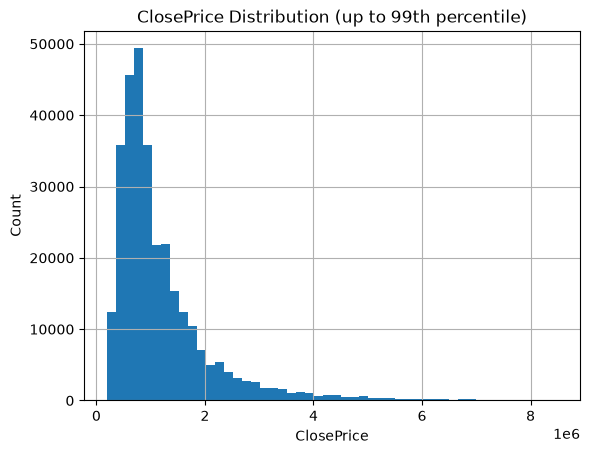

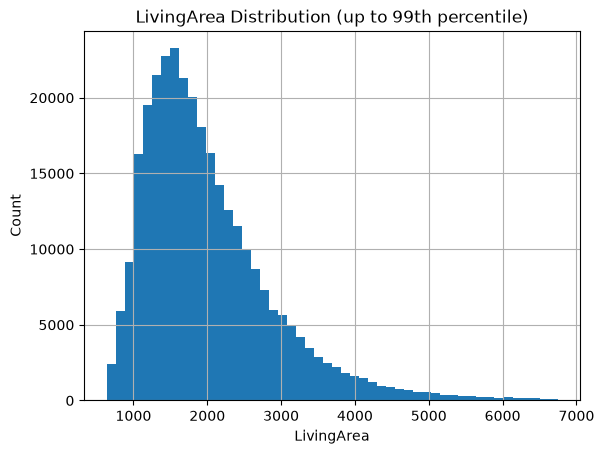

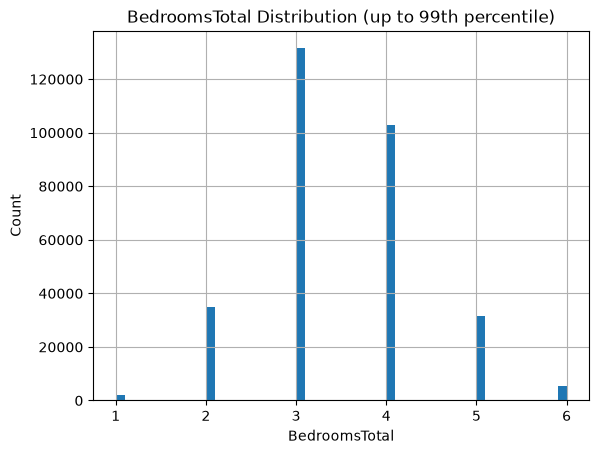

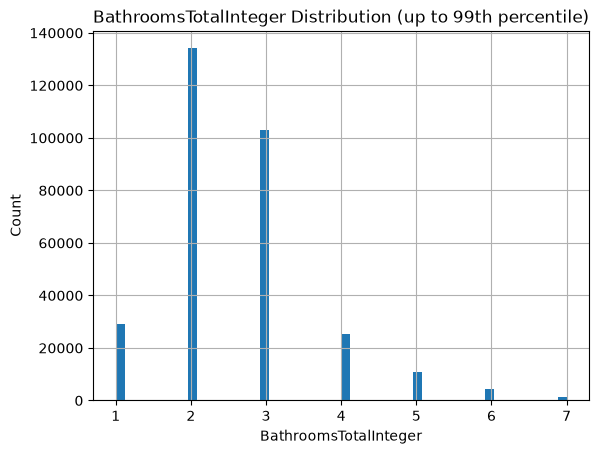

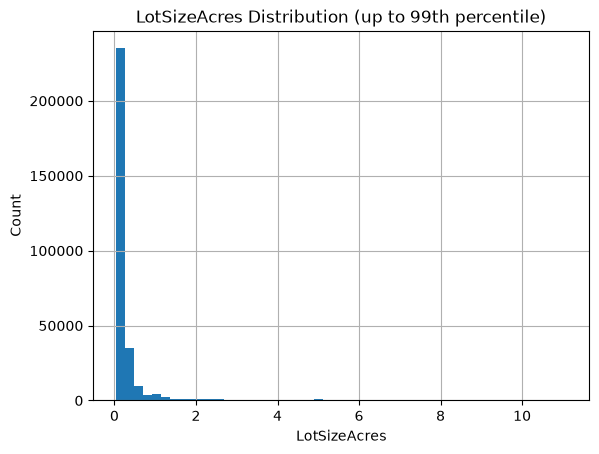

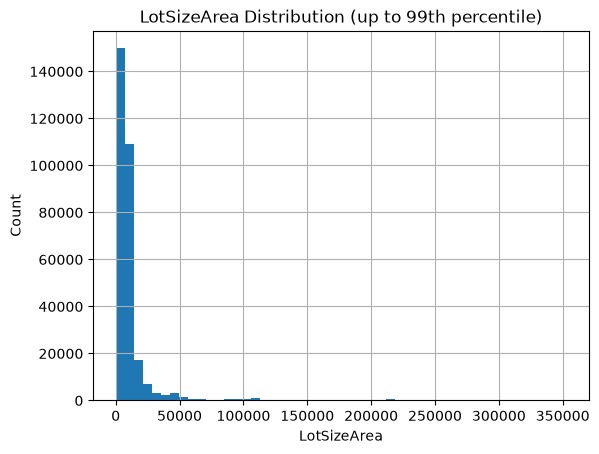

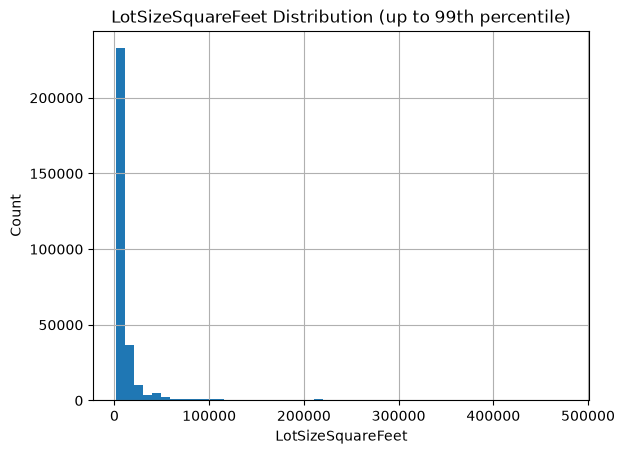

In [16]:
for col in cols:
    upper = df_res[col].quantile(0.995)
    lower = df_res[col].quantile(0.005)
    trimmed = df_res[(df_res[col] <= upper) & (df_res[col] >= lower) & (df_res[col].notna())]

    trimmed[col].hist(bins=50)
    plt.title(f"{col} Distribution (up to 99th percentile)")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

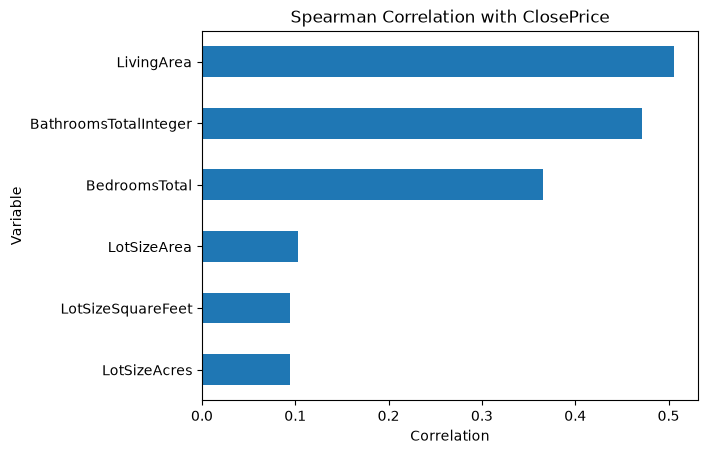

In [17]:
# graph out Spearman correlation coefficients for ClosePrice and columns from cols
correlations = (df_res[cols].corr(method="spearman")["ClosePrice"].drop("ClosePrice").sort_values())

correlations.plot(kind="barh")

plt.title("Spearman Correlation with ClosePrice")
plt.xlabel("Correlation")
plt.ylabel("Variable")
plt.show()

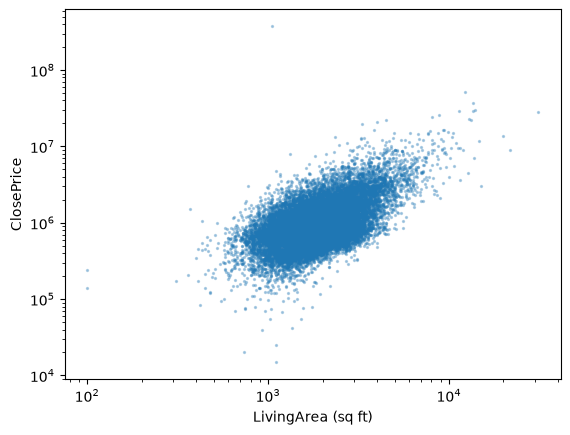

In [18]:
# graphs out LivingArea with ClosePrice
df_res[cols].corr(method="spearman")["ClosePrice"].sort_values(ascending=False)
#gets random sample of 20,000 rows
sample = df_res.sample(20_000, random_state=0)
plt.scatter(sample["LivingArea"], sample["ClosePrice"], s=2, alpha=0.3)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("LivingArea (sq ft)"); plt.ylabel("ClosePrice")
plt.show() # larger LivingArea tend to have higher ClosePrices 